In [1]:
import sys, os, time, math, random
import multiprocessing
import numpy as np
import numba
from numba import njit,prange
from joblib import Parallel, delayed

In [2]:
#Base
# the algorithm was taken from https://pythonmania.org/python-program-for-sieve-of-eratosthenes/
def sieve_of_eratosthenes(n):
    primes = [True] * (n+1)
    primes[0] = primes[1] = False

    p = 2
    while p * p <= n:
        if primes[p]:
            for i in range(p * p, n+1, p):
                primes[i] = False
        p += 1

    return [i for i, prime in enumerate(primes) if prime]


In [3]:
#Numpy
def sieve_of_eratosthenes_np(n):
    primes = np.ones(n+1,dtype=bool)
    primes[0] = primes[1] = False
    

    p = 2
    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = False
        p += 1

    return [i for i, prime in enumerate(primes) if prime]

In [4]:
#Numba
@njit(nogil=True, parallel=True)
def sieve_of_eratosthenes_numba(n):
    primes = np.ones(n+1,dtype=np.uint8)#Numba doesn't support boolean values
    primes[0] = primes[1] = 0

    p = 2
    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = 0
        p += 1

    return [i for i, prime in enumerate(primes) if prime]

In [5]:
sieve_of_eratosthenes_numba(100000)

[2,
 3,
 5,
 7,
 11,
 13,
 17,
 19,
 23,
 29,
 31,
 37,
 41,
 43,
 47,
 53,
 59,
 61,
 67,
 71,
 73,
 79,
 83,
 89,
 97,
 101,
 103,
 107,
 109,
 113,
 127,
 131,
 137,
 139,
 149,
 151,
 157,
 163,
 167,
 173,
 179,
 181,
 191,
 193,
 197,
 199,
 211,
 223,
 227,
 229,
 233,
 239,
 241,
 251,
 257,
 263,
 269,
 271,
 277,
 281,
 283,
 293,
 307,
 311,
 313,
 317,
 331,
 337,
 347,
 349,
 353,
 359,
 367,
 373,
 379,
 383,
 389,
 397,
 401,
 409,
 419,
 421,
 431,
 433,
 439,
 443,
 449,
 457,
 461,
 463,
 467,
 479,
 487,
 491,
 499,
 503,
 509,
 521,
 523,
 541,
 547,
 557,
 563,
 569,
 571,
 577,
 587,
 593,
 599,
 601,
 607,
 613,
 617,
 619,
 631,
 641,
 643,
 647,
 653,
 659,
 661,
 673,
 677,
 683,
 691,
 701,
 709,
 719,
 727,
 733,
 739,
 743,
 751,
 757,
 761,
 769,
 773,
 787,
 797,
 809,
 811,
 821,
 823,
 827,
 829,
 839,
 853,
 857,
 859,
 863,
 877,
 881,
 883,
 887,
 907,
 911,
 919,
 929,
 937,
 941,
 947,
 953,
 967,
 971,
 977,
 983,
 991,
 997,
 1009,
 1013,
 1019,


In [6]:
%load_ext Cython

In [7]:
%%cython --compile-args=-fopenmp --link-args=-fopenmp

import numpy as np
cimport numpy as cnp

def sieve_of_eratosthenes_cython(int n):
    cdef cnp.ndarray[cnp.uint8_t, ndim=1] primes = np.ones(n+1, dtype=np.uint8)
    cdef int p = 2

    primes[0] = 0
    primes[1] = 0
    

    while p * p <= n:
        if primes[p]:
            primes[p * p::p] = 0
        p += 1
    return np.where(primes)[0]

In [8]:
#Joblib

def sieve(lim): # find all prime numbers up to sqrt(n), i.e. the base prime numbers
    primes = [True] * (lim + 1)
    primes[0] = primes[1] = False

    for i in range(2,int(math.sqrt(lim)) + 1):
        if primes[i]:
            for j in range(i*i, lim + 1,i):
                primes[j] = False
    return [i for i, prime in enumerate(primes) if prime]

def chunk_sieve(start,end,base):#find all prime numbers from sqrt(n) to n (by sieving off the products of the base prime numbers)
    chunk = [True] * (end - start)

    for p in base:
        first = max(p * p, ((start + p -1) // p) * p)
        for i in range(first,end,p):
            chunk[i - start] = False
    return [i + start for i, prime in enumerate(chunk) if prime and i + start >= 2]

def sieve_of_eratosthenes_joblib(n, n_jobs):
    lim = int(math.sqrt(n))
    base = sieve(lim)

    chunk_size = (n - lim) // n_jobs + 1
    chunks = [
        (start, min(start + chunk_size,n+1)) for start in range(lim + 1,n + 1, chunk_size)
    ]
    
    chunk_out = Parallel(n_jobs=n_jobs)(
        delayed(chunk_sieve)(start,end,base) for start, end in chunks
    )
    combined_primes = base[:]
    for p in chunk_out:
        combined_primes.extend(p)
    return combined_primes
    
    
    

In [9]:
def sieve(lim): # find all prime numbers up to sqrt(n), i.e. the base prime numbers
    primes = [True] * (lim + 1)
    primes[0] = primes[1] = False

    for i in range(2,int(math.sqrt(lim)) + 1):
        if primes[i]:
            for j in range(i*i, lim + 1,i):
                primes[j] = False
    return [i for i, prime in enumerate(primes) if prime]

def chunk_sieve(start,end,base):#find all prime numbers from sqrt(n) to n (by sieving off the products of the base prime numbers)
    chunk = [True] * (end - start)

    for p in base:
        first = max(p * p, ((start + p -1) // p) * p)
        for i in range(first,end,p):
            chunk[i - start] = False
    return [i + start for i, prime in enumerate(chunk) if prime and i + start >= 2]

def sieve_of_eratosthenes_multip(n, n_jobs):
    lim = int(math.sqrt(n))
    base = sieve(lim)

    chunk_size = (n - lim) // n_jobs + 1
    chunks = [
        (start, min(start + chunk_size,n+1)) for start in range(lim + 1,n + 1, chunk_size)
    ]
    with multiprocessing.Pool(processes=n_jobs) as pool:
        chunk_out = pool.starmap(chunk_sieve,[(start,end,base) for start, end in chunks])
    combined_primes = base[:]
    for p in chunk_out:
        combined_primes.extend(p)
    return combined_primes

In [10]:
numba.set_num_threads(4)

27 μs ± 124 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
28.2 μs ± 8.61 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
5.07 μs ± 2.39 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.27 μs ± 1.13 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.2 ms ± 2.02 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
10.7 ms ± 544 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
323 μs ± 14.9 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
195 μs ± 1.9 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
24.8 μs ± 1.19 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
27.4 μs ± 1.88 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
10.4 ms ± 35.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.1 ms ± 510 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
3.3 ms ± 41.1 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
1.8 ms ± 16.9 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
190 μs ± 2.92 μs

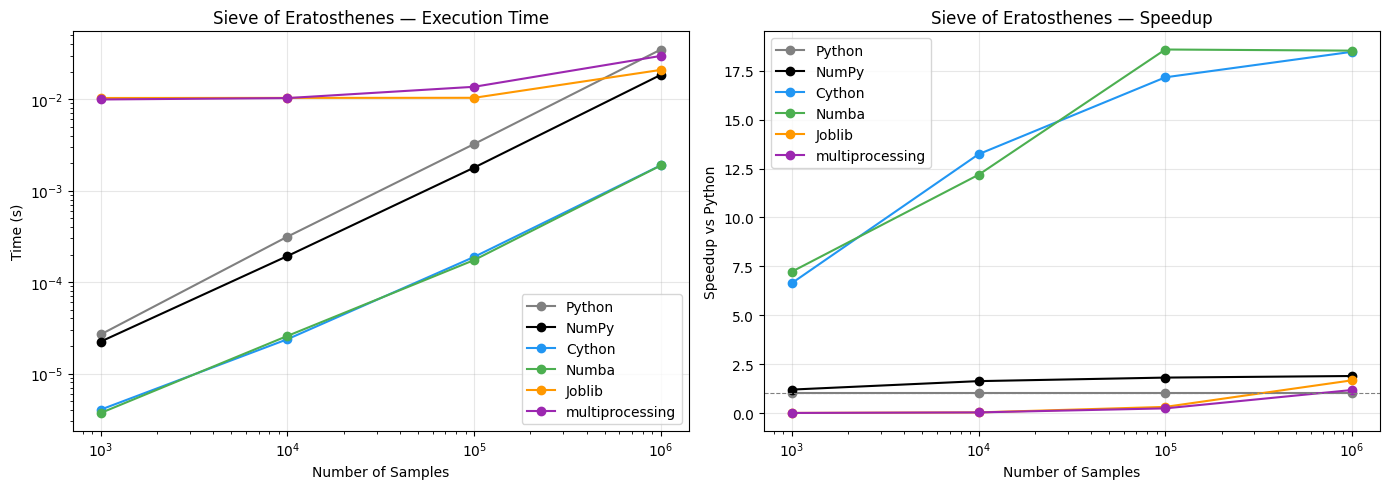

In [11]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 4)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 4)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosthenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosthenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_4.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
numba.set_num_threads(8)

27.8 μs ± 457 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
22.8 μs ± 884 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.82 μs ± 1.84 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
5.59 μs ± 2.11 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.2 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
26.1 ms ± 1.69 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
333 μs ± 16.2 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
196 μs ± 1.25 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
24.4 μs ± 821 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
24 μs ± 1.57 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
10.5 ms ± 34.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
26.2 ms ± 5.23 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
3.31 ms ± 50.3 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
1.86 ms ± 20.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
199 μs ± 2.5 

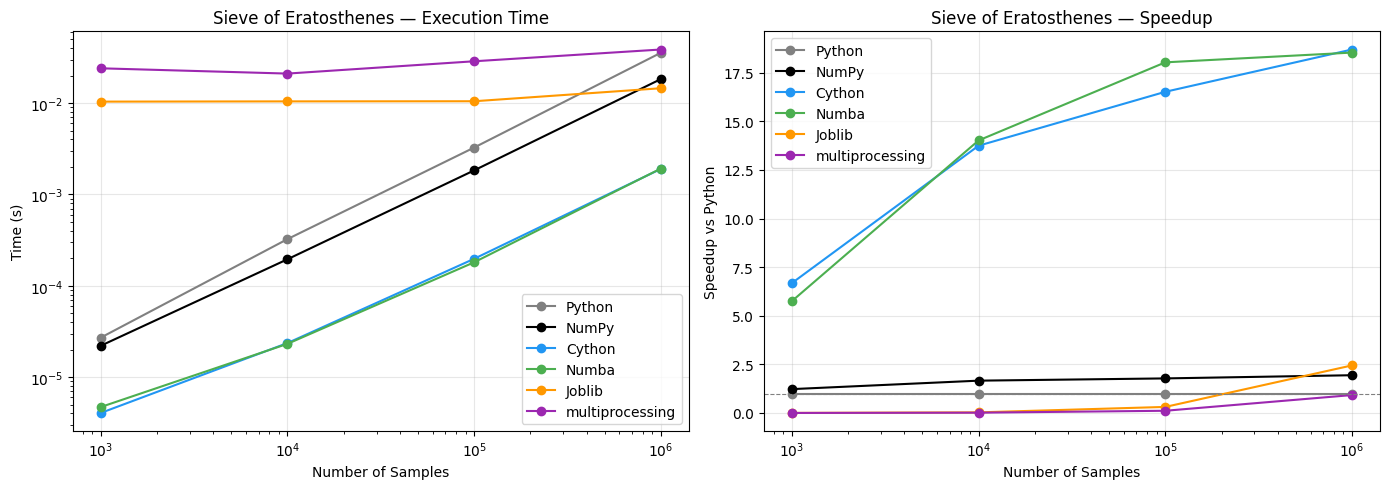

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 8)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 8)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosthenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosthenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_8.png', dpi=150, bbox_inches='tight')
plt.show()

32.4 μs ± 2.63 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
22 μs ± 770 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.44 μs ± 894 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.3 μs ± 743 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
11.8 ms ± 2.76 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
59.5 ms ± 13.1 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
311 μs ± 4.46 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
190 μs ± 762 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
24.6 μs ± 715 ns per loop (mean ± std. dev. of 7 runs, 20 loops each)
23.6 μs ± 1.05 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
10.6 ms ± 43.9 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
54.1 ms ± 5.78 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
3.39 ms ± 35.2 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
1.91 ms ± 23.3 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
199 μs ± 3.86 μs

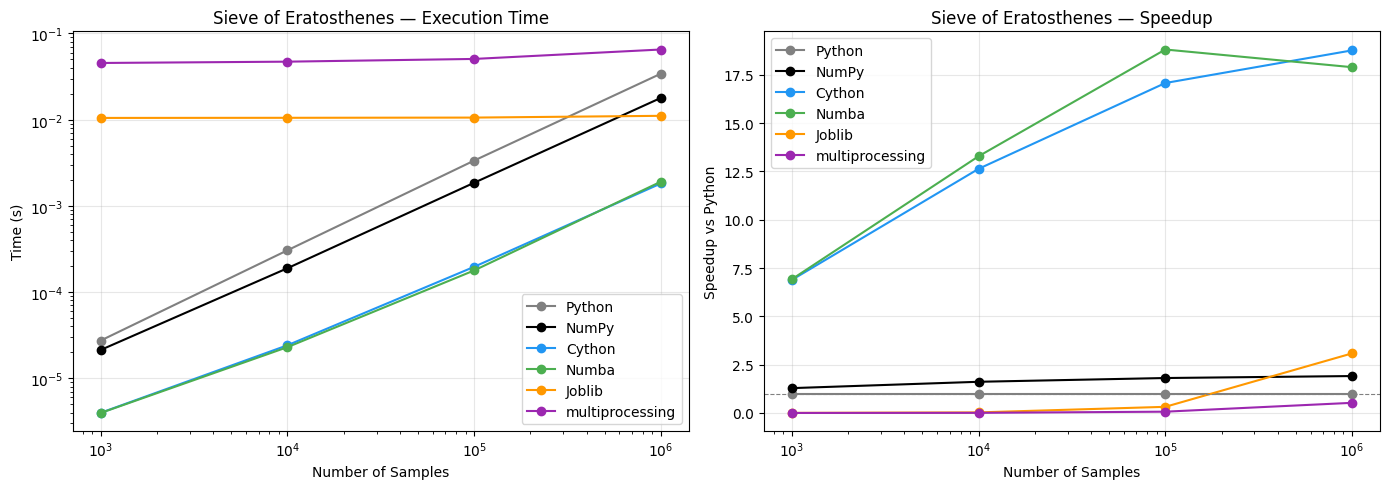

In [14]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 sieve_of_eratosthenes(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_cython(n)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_joblib(n, 16)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 sieve_of_eratosthenes_multip(n, 16)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Sieve of Eratosthenes — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Sieve of Eratosthenes — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sieve_results_16.png', dpi=150, bbox_inches='tight')
plt.show()